<a href="https://colab.research.google.com/github/Danchi-1/COVID_data_analysis/blob/main/DSNHack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import pandas and load both train.csv and test.csv files. Display basic information about the datasets including shape, column names, and data types. This step helps us understand what features we're working with and identify any immediate data quality issues.

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [34]:
try:
  train_df = pd.read_csv('train.csv')
  test_df = pd.read_csv('test.csv')
  print(f"Training dataset: {train_df.shape}")
  print(f"Test dataset: {test_df.shape}")
  print(f"Datatype for train dataset: {train_df.dtypes}")
  print(f"Datatype for test dataset: {test_df.dtypes}")
  target_col = 'price'
  if target_col is None:
    target_col = train_df.columns[-1]
  print(f"Target Stats: {train_df[target_col].describe()}")
except Exception as e:
  print('File not found in location provided. Input correct file location')

for col in train_df.columns.tolist():
  missing_train_dataset = train_df[col].isnull().sum()
for col in test_df.columns.tolist():
  missing_test_dataset = test_df[col].isnull().sum()
print(f"The number of missing values in train.csv is {missing_train_dataset} and the that of test.csv is {missing_test_dataset}")

Training dataset: (188533, 13)
Test dataset: (125690, 12)
Datatype for train dataset: id               int64
brand           object
model           object
model_year       int64
milage           int64
fuel_type       object
engine          object
transmission    object
ext_col         object
int_col         object
accident        object
clean_title     object
price            int64
dtype: object
Datatype for test dataset: id               int64
brand           object
model           object
model_year       int64
milage           int64
fuel_type       object
engine          object
transmission    object
ext_col         object
int_col         object
accident        object
clean_title     object
dtype: object
Target Stats: count    1.885330e+05
mean     4.387802e+04
std      7.881952e+04
min      2.000000e+03
25%      1.700000e+04
50%      3.082500e+04
75%      4.990000e+04
max      2.954083e+06
Name: price, dtype: float64
The number of missing values in train.csv is 0 and the that of tes

Understand the relationships between features and the target variable, and identify patterns in the data.

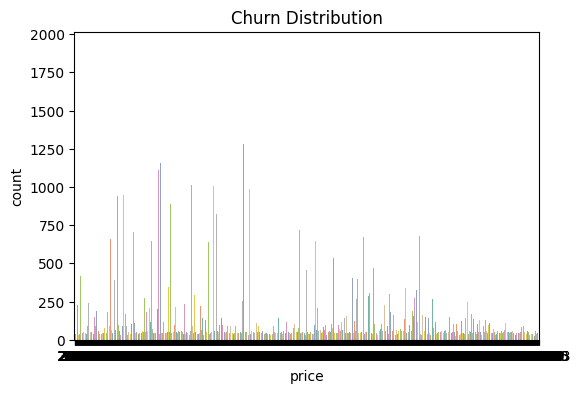

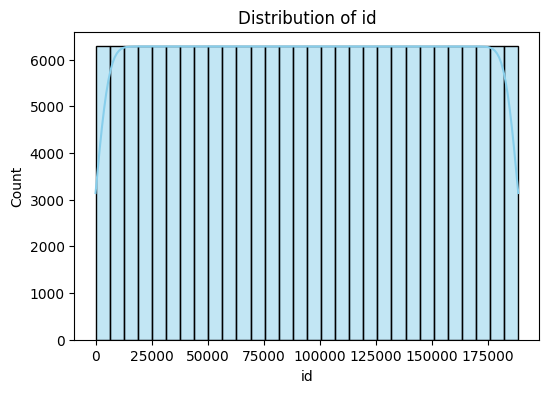

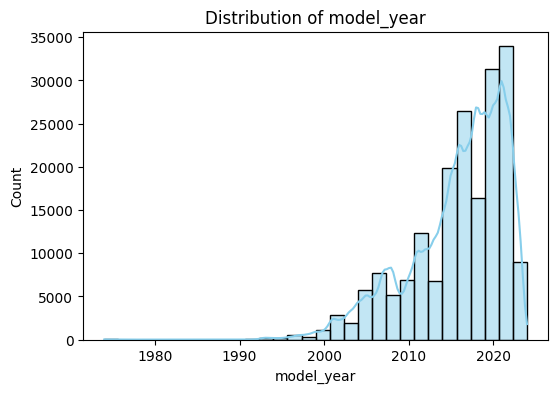

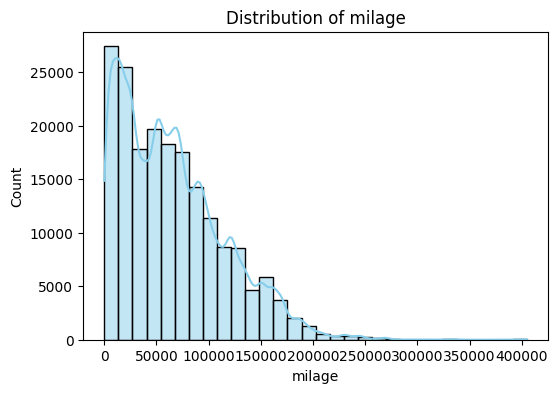

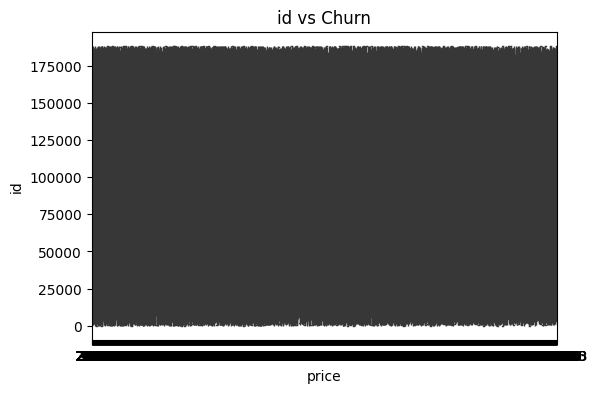

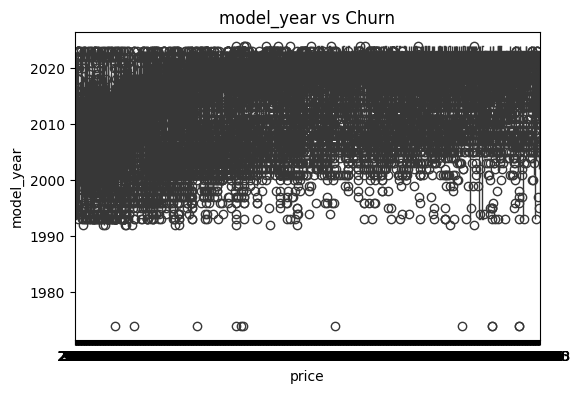

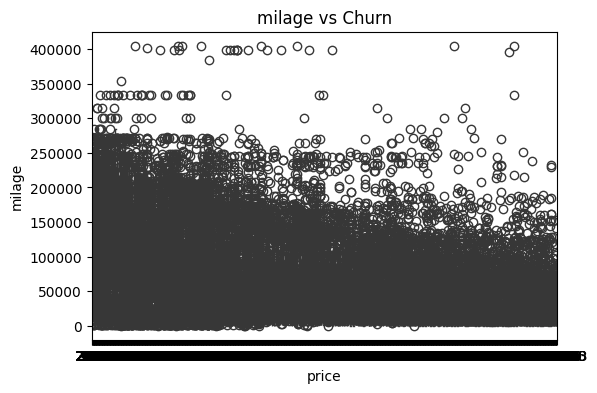

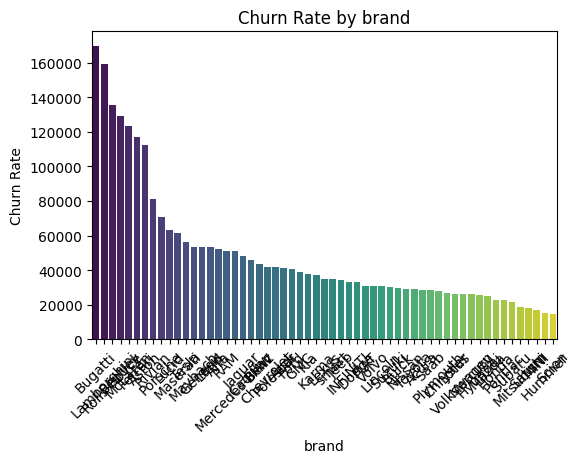

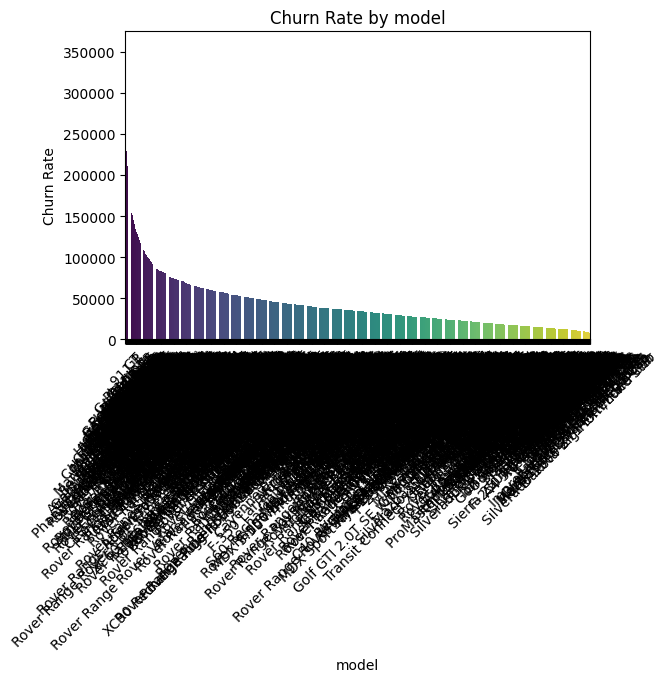

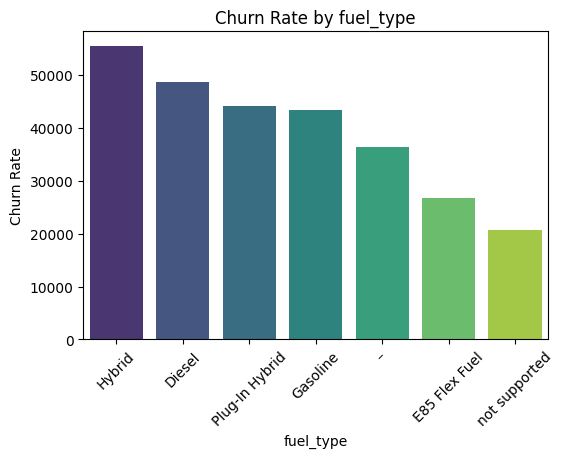

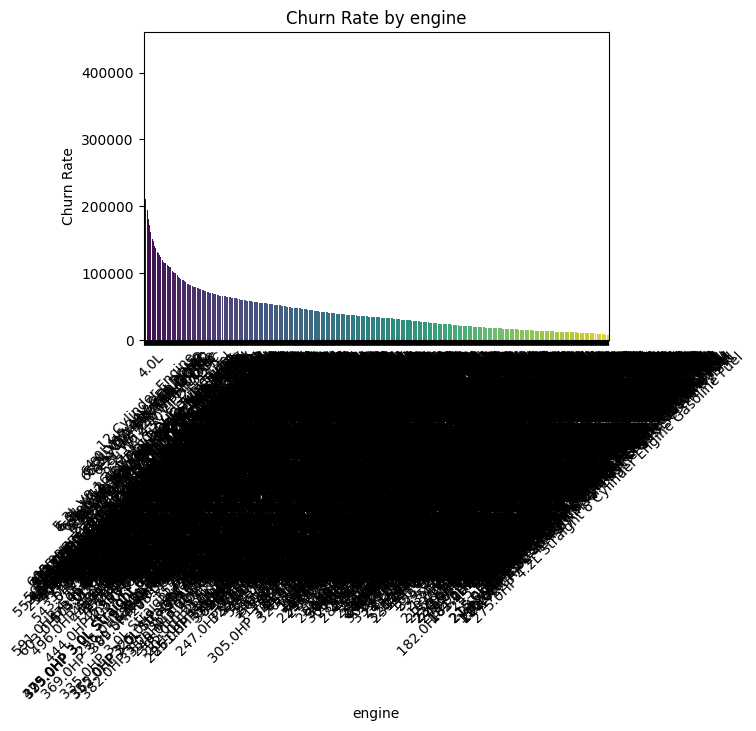

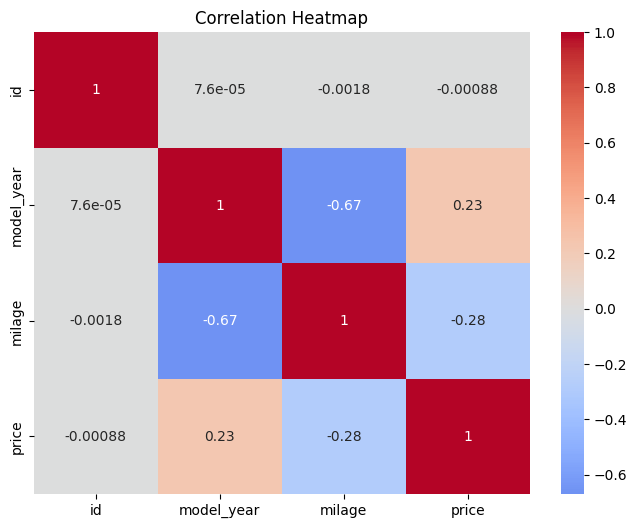

In [35]:
# Target variable distribution
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=train_df, palette="Set2")
plt.title("Churn Distribution")
plt.show()

# Numerical feature distributions
numerical_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numerical_cols:
    numerical_cols.remove(target_col)

for col in numerical_cols[:4]:  # show first 4 numerical features
    plt.figure(figsize=(6,4))
    sns.histplot(train_df[col], kde=True, bins=30, color="skyblue")
    plt.title(f"Distribution of {col}")
    plt.show()

# Boxplots for numerical features vs churn
for col in numerical_cols[:4]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=target_col, y=col, data=train_df, palette="coolwarm")
    plt.title(f"{col} vs Churn")
    plt.show()

# Bar plots for categorical features vs churn
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols[:4]:
    plt.figure(figsize=(6,4))
    churn_rate = train_df.groupby(col)[target_col].mean().sort_values(ascending=False)
    sns.barplot(x=churn_rate.index, y=churn_rate.values, palette="viridis")
    plt.xticks(rotation=45)
    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Churn Rate")
    plt.show()

# Correlation heatmap for numerical features
if len(numerical_cols) > 1:
    plt.figure(figsize=(8,6))
    corr_matrix = train_df[numerical_cols + [target_col]].corr()
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
    plt.title("Correlation Heatmap")
    plt.show()


Handle missing values, create new features, and transform existing ones.

In [36]:
def handle_missing_values(df):
    df_filled = df.copy()
    for col in df_filled.columns:
        if df_filled[col].isnull().sum() > 0:
            if df_filled[col].dtype in ['int64', 'float64']:
                fill_value = df_filled[col].median()
                df_filled[col].fillna(fill_value, inplace=True)
            else:
                fill_value = df_filled[col].mode()[0] if not df_filled[col].mode().empty else 'Unknown'
                df_filled[col].fillna(fill_value, inplace=True)
    return df_filled

train_processed = handle_missing_values(train_df)
test_processed = handle_missing_values(test_df)

def create_features(df):
    df_new = df.copy()

    # Example: tenure grouping
    if 'tenure' in df_new.columns:
        df_new['tenure_group'] = pd.cut(df_new['tenure'],
                                        bins=[0, 12, 24, 48, 60, float('inf')],
                                        labels=['0-12', '12-24', '24-48', '48-60', '60+'])

    # Example: Average monthly charges per tenure
    if 'MonthlyCharges' in df_new.columns and 'tenure' in df_new.columns:
        df_new['avg_charge_per_month'] = df_new['MonthlyCharges'] / (df_new['tenure'] + 1)

    return df_new

train_processed = create_features(train_processed)
test_processed = create_features(test_processed)


Convert categorical variables into numeric form using Label Encoding or One-Hot Encoding.

In [37]:
categorical_cols = train_processed.select_dtypes(include=['object']).columns.tolist()
label_encoders = {}

def encode_categorical_features(train_df, test_df, categorical_columns):
    train_encoded = train_df.copy()
    test_encoded = test_df.copy()

    for col in categorical_columns:
        if col in train_encoded.columns:
            unique_values = train_encoded[col].nunique()

            if unique_values <= 10:  # one-hot encoding
                train_dummies = pd.get_dummies(train_encoded[col], prefix=col)
                test_dummies = pd.get_dummies(test_encoded[col], prefix=col)
                for dummy_col in train_dummies.columns:
                    if dummy_col not in test_dummies.columns:
                        test_dummies[dummy_col] = 0
                test_dummies = test_dummies[train_dummies.columns]
                train_encoded = pd.concat([train_encoded.drop(col, axis=1), train_dummies], axis=1)
                test_encoded = pd.concat([test_encoded.drop(col, axis=1), test_dummies], axis=1)
            else:  # label encoding
                le = LabelEncoder()
                train_encoded[col] = le.fit_transform(train_encoded[col].astype(str))
                test_encoded[col] = test_encoded[col].astype(str).map(lambda x: le.transform([x])[0] if x in le.classes_ else -1)
                label_encoders[col] = le

    return train_encoded, test_encoded

train_encoded, test_encoded = encode_categorical_features(train_processed, test_processed, categorical_cols)


In [38]:
X = train_encoded.drop(target_col, axis=1)
y = train_encoded[target_col]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_scaled = scaler.fit_transform(X)  # for CV


Train multiple models and compare them.

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'LightGBM': lgb.LGBMClassifier(random_state=42)
}

def evaluate_model(y_true, y_pred, y_prob):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_prob)
    }

results = {}
trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]
    results[name] = evaluate_model(y_val, y_pred, y_prob)
    print(results[name])



Training Logistic Regression...


In [ ]:
def tune_random_forest(X, y):
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }
    rf = RandomForestClassifier(random_state=42)
    grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
    grid_search.fit(X, y)
    return grid_search.best_estimator_

def tune_xgboost(X, y):
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [3, 6, 10],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0]
    }
    xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
    grid_search = GridSearchCV(xgb_model, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
    grid_search.fit(X, y)
    return grid_search.best_estimator_

tuned_models = {}
tuned_models['Random Forest Tuned'] = tune_random_forest(X_train, y_train)
tuned_models['XGBoost Tuned'] = tune_xgboost(X_train, y_train)


Combine top models for better performance.

In [ ]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(estimators=[
    ('rf', trained_models['Random Forest']),
    ('xgb', trained_models['XGBoost']),
    ('lgb', trained_models['LightGBM'])
], voting='soft')

ensemble.fit(X_train, y_train)
y_pred = ensemble.predict(X_val)
y_prob = ensemble.predict_proba(X_val)[:, 1]

print("Ensemble Performance:", evaluate_model(y_val, y_pred, y_prob))
